# Multiobjective Evolutionary Algorithm based on Decomposition
-- Uvini Balasuriya and Divya Ramachandran

All the imports

In [2]:
import pandas as pd
import numpy as np
from pymoo.problems import get_problem
import sklearn

In [3]:
import matplotlib.pyplot as plt

from pymoo.optimize import minimize
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.algorithms.moo.rvea import RVEA
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.indicators.hv import HV
from pymoo.indicators.igd import IGD



Function for implementing moea-d

In [4]:
# Function to evaluate the problem
def evaluate(problem, x):
    """Evaluate the problem for a given input vector.
    
    problem: The problem instance from pymoo
    x: The input vector to evaluate
    """
    return problem.evaluate(x.reshape(1, -1))[0]


# Function to generate weights vectors
# MOEA-D relies on evenly distributed weight vectors to decompose the multi-objective problem into scalar subproblems.

def generate_weights(N, M):

    """
    Generate weight vectors for MOEA-D.
    N: Number of weight vectors (population size)
    M: Number of objectives
    """

    if M == 2:
        return np.array([[i/(N-1), 1 - i/(N-1)] for i in range(N)])
    else:
        # fallback random for higher dimensions
        W = np.random.rand(N, M)
        return W / W.sum(axis=1, keepdims=True)
    
    
# Neighbourhood function to find the closest weight vectors
def find_neighbors(W, T):
    """
    Find the T closest weight vectors for each weight vector in W.
    W: Weight vectors
    T: Number of neighbors
    """
    from sklearn.metrics import pairwise_distances
    distances = pairwise_distances(W)
    neighbors = np.argsort(distances, axis=1)[:, :T]
    return neighbors


# Iniitalize population
def initialize_population(problem, N):
    """
    Initialize the population for MOEA-D.
    """
    X = np.random.uniform(problem.xl, problem.xu, (N, problem.n_var))
    F = problem.evaluate(X)
    return X, F


# Initialize ideal point Z*
def initialize_ideal_point(F):
    """
    Initialize the ideal point Z* based on the initial population's objective values.
    F: Objective values of the initial population
    """
    return np.min(F, axis=0)


# Decomposition function to solve scalar subproblems
def g(f, w, z):
    """
    Tchebycheff decomposition function.

    f: objective vector of ONE solution (shape: M,)
    w: ONE weight vector (shape: M,)
    z: ideal point (shape: M,)

    returns: scalar value
    """
    # return np.max(w * np.abs(f - z)) 
    return np.max(np.maximum(w, 1e-6) * np.abs(f - z))


# Function to select parents for reproduction
def select_parents(i, B, N, delta):
    """
    Select parents for reproduction based on the neighborhood structure.
        i: Index of the current subproblem
        B: Neighborhood structure (list of neighbors for each subproblem)
        N: Total population size
        delta: Probability of selecting from the neighborhood
    """

    if np.random.rand() < delta:
        P = B[i]            # neighbors
    else:
        P = np.arange(N)    # whole population

    k, l = np.random.choice(P, 2, replace=False)
    return k, l


def variation(x1, x2, xl, xu):
    """
    x1, x2: parent solutions (1D arrays)
    xl, xu: lower/upper bounds (from problem)

    returns: offspring y
    """

    # Crossover (blend parents)
    alpha = np.random.rand()
    y = alpha * x1 + (1 - alpha) * x2

    # Mutation (add small noise)
    sigma = 0.03  # mutation strength (tune if needed)
    noise = sigma * (xu - xl) * np.random.randn(len(x1))
    y = y + noise

    # Clip to bounds
    y = np.clip(y, xl, xu)

    return y


def moead(problem, N=100, T=10, delta=0.9, max_gen=200):

    # Step 1: weights
    W = generate_weights(N, problem.n_obj)

    # Step 2: neighbors
    B = find_neighbors(W, T)

    # Step 3: population
    X, F = initialize_population(problem, N)

    # Step 4: ideal point
    z = initialize_ideal_point(F)

    # Step 5: main loop
    for gen in range(max_gen):

        for i in range(N):

            # parent selection
            k, l = select_parents(i, B, N, delta)

            # variation
            y = variation(X[k], X[l], problem.xl, problem.xu)

            # evaluation
            f_y = evaluate(problem, y)

            # update ideal point
            z = np.minimum(z, f_y)

            # update neighbors
            for j in B[i]:
                if g(f_y, W[j], z) <= g(F[j], W[j], z):
                    X[j] = y
                    F[j] = f_y

    return X, F

Execution Code

[[0.9636863  0.07374697]
 [0.91973115 0.08005954]
 [0.91668786 0.08815093]
 [0.90783864 0.10171439]
 [0.87937186 0.10971124]
 [0.86221624 0.11717933]
 [0.83044279 0.12450933]
 [0.81637504 0.1356773 ]
 [0.79438106 0.14051859]
 [0.78471907 0.15290377]]


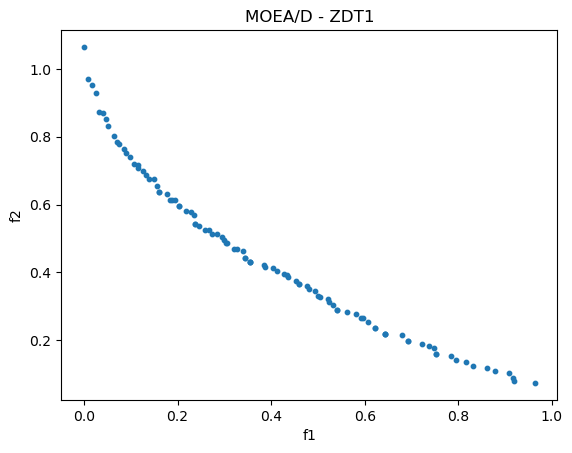

In [5]:
problem = get_problem("zdt1")

X, F = moead(problem, N=100, T=20, delta=0.7, max_gen=1000)

print(F[:10])   # show first 10 objective values

import matplotlib.pyplot as plt

plt.scatter(F[:, 0], F[:, 1], s=10)
plt.xlabel("f1")
plt.ylabel("f2")
plt.title("MOEA/D - ZDT1")
plt.show()

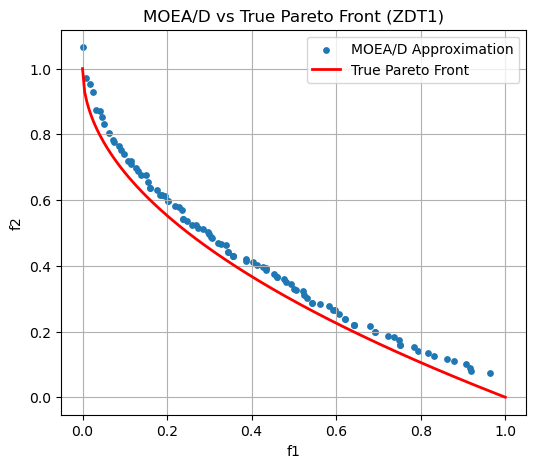

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Your result (already computed)
# F = output from MOEA/D

# True Pareto front
f1_true = np.linspace(0, 1, 200)
f2_true = 1 - np.sqrt(f1_true)

# Plot
plt.figure(figsize=(6,5))

# Your solutions
plt.scatter(F[:, 0], F[:, 1], s=15, label="MOEA/D Approximation")

# True front
plt.plot(f1_true, f2_true, 'r-', linewidth=2, label="True Pareto Front")

plt.xlabel("f1")
plt.ylabel("f2")
plt.title("MOEA/D vs True Pareto Front (ZDT1)")
plt.legend()
plt.grid(True)

plt.show()

In [7]:
# --------------------------------------------------
# Non-dominated sorting helper
# --------------------------------------------------
def non_dominated_mask(F):
    n = len(F)
    mask = np.ones(n, dtype=bool)

    for i in range(n):
        for j in range(n):
            if i != j:
                if np.all(F[j] <= F[i]) and np.any(F[j] < F[i]):
                    mask[i] = False
                    break
    return mask


In [8]:
# --------------------------------------------------
# Fixed MOEA/D with history
# --------------------------------------------------
def moead_with_history(problem, N=100, T=20, delta=0.9, max_gen=200):
    W = generate_weights(N, problem.n_obj)
    B = find_neighbors(W, T)

    X, F = initialize_population(problem, N)
    z = initialize_ideal_point(F)

    history_F = []
    all_F = []
    all_gen = []

    for gen in range(max_gen):
        for i in range(N):
            k, l = select_parents(i, B, N, delta)

            y = variation(X[k], X[l], problem.xl, problem.xu)
            f_y = evaluate(problem, y)

            z = np.minimum(z, f_y)

            for j in B[i]:
                if g(f_y, W[j], z) <= g(F[j], W[j], z):
                    X[j] = y
                    F[j] = f_y

            all_F.append(f_y)
            all_gen.append(gen)

        history_F.append(F.copy())

    return X, F, history_F, np.array(all_F), np.array(all_gen)


In [9]:
# --------------------------------------------------
# Simple weighted-sum baseline
# --------------------------------------------------
def weighted_sum_baseline(problem, N=100, max_gen=200):
    W = generate_weights(N, problem.n_obj)

    X, F = initialize_population(problem, N)

    history_F = []
    all_F = []
    all_gen = []

    for gen in range(max_gen):
        for i in range(N):
            p1, p2 = np.random.choice(N, 2, replace=False)

            y = variation(X[p1], X[p2], problem.xl, problem.xu)
            f_y = evaluate(problem, y)

            old_score = np.sum(W[i] * F[i])
            new_score = np.sum(W[i] * f_y)

            if new_score <= old_score:
                X[i] = y
                F[i] = f_y

            all_F.append(f_y)
            all_gen.append(gen)

        history_F.append(F.copy())

    return X, F, history_F, np.array(all_F), np.array(all_gen)



In [10]:
# --------------------------------------------------
# Pymoo reference methods
# --------------------------------------------------
def run_nsga2(problem, pop_size=100, generations=200, seed=1):
    algorithm = NSGA2(pop_size=pop_size)

    res = minimize(
        problem,
        algorithm,
        ("n_gen", generations),
        seed=seed,
        save_history=True,
        verbose=False
    )

    history_F = [algo.pop.get("F").copy() for algo in res.history]
    all_F = np.vstack(history_F)
    all_gen = np.concatenate([
        np.full(len(history_F[g]), g) for g in range(len(history_F))
    ])

    return res.X, res.F, history_F, all_F, all_gen

def run_rvea(problem, pop_size=100, generations=200, seed=1):
    ref_dirs = get_reference_directions(
        "das-dennis",
        problem.n_obj,
        n_partitions=pop_size - 1
    )

    algorithm = RVEA(ref_dirs=ref_dirs)

    res = minimize(
        problem,
        algorithm,
        ("n_gen", generations),
        seed=seed,
        save_history=True,
        verbose=False
    )

    history_F = [algo.pop.get("F").copy() for algo in res.history]
    all_F = np.vstack(history_F)
    all_gen = np.concatenate([
        np.full(len(history_F[g]), g) for g in range(len(history_F))
    ])

    return res.X, res.F, history_F, all_F, all_gen


In [11]:
# --------------------------------------------------
# Metric curves
# --------------------------------------------------
def compute_metric_curves(history_F, true_pf, ref_point):
    hv_indicator = HV(ref_point=ref_point)
    igd_indicator = IGD(true_pf)

    hv_values = []
    igd_values = []

    for F in history_F:
        nd = F[non_dominated_mask(F)]

        hv_values.append(hv_indicator(nd))
        igd_values.append(igd_indicator(nd))

    return np.array(hv_values), np.array(igd_values)


In [12]:
# --------------------------------------------------
# Plotting functions
# --------------------------------------------------
def plot_final_pareto(problem_name, results, true_pf):
    plt.figure(figsize=(7, 5))

    plt.plot(
        true_pf[:, 0],
        true_pf[:, 1],
        "k--",
        linewidth=2,
        label="True Pareto Front"
    )

    for method, data in results.items():
        F = data["F"]
        nd = F[non_dominated_mask(F)]
        plt.scatter(nd[:, 0], nd[:, 1], s=18, label=method)

    plt.xlabel("Objective 1")
    plt.ylabel("Objective 2")
    plt.title(f"Final Pareto Front Comparison - {problem_name.upper()}")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_colored_trials(problem_name, method_name, all_F, all_gen):
    plt.figure(figsize=(7, 5))

    sc = plt.scatter(
        all_F[:, 0],
        all_F[:, 1],
        c=all_gen,
        s=8,
        cmap="Blues",
        alpha=0.6
    )

    plt.colorbar(sc, label="Generation")
    plt.xlabel("Objective 1")
    plt.ylabel("Objective 2")
    plt.title(f"{method_name} Search Progress - {problem_name.upper()}")
    plt.grid(True)
    plt.show()


def plot_pareto_highlight(problem_name, method_name, all_F):
    nd_mask = non_dominated_mask(all_F)
    nd = all_F[nd_mask]

    plt.figure(figsize=(7, 5))

    plt.scatter(
        all_F[:, 0],
        all_F[:, 1],
        s=8,
        alpha=0.25,
        label="All evaluated solutions"
    )

    plt.scatter(
        nd[:, 0],
        nd[:, 1],
        s=20,
        color="red",
        label="Non-dominated / Pareto front"
    )

    plt.xlabel("Objective 1")
    plt.ylabel("Objective 2")
    plt.title(f"Pareto Front Highlight - {method_name} on {problem_name.upper()}")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_hv_curves(problem_name, results):
    plt.figure(figsize=(7, 5))

    for method, data in results.items():
        plt.plot(data["hv"], label=method)

    plt.xlabel("Generation")
    plt.ylabel("Hypervolume")
    plt.title(f"Hypervolume over Generations - {problem_name.upper()}")
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_igd_curves(problem_name, results):
    plt.figure(figsize=(7, 5))

    for method, data in results.items():
        plt.plot(data["igd"], label=method)

    plt.xlabel("Generation")
    plt.ylabel("IGD")
    plt.title(f"IGD over Generations - {problem_name.upper()}")
    plt.legend()
    plt.grid(True)
    plt.show()


In [13]:
# --------------------------------------------------
# Full experiment runner
# --------------------------------------------------
def run_all_experiments(
    problem_names=("zdt1", "zdt2", "zdt3"),
    pop_size=100,
    generations=200,
    seed=1
):
    all_results = {}

    for problem_name in problem_names:
        print(f"\nRunning experiments for {problem_name.upper()}...")

        problem = get_problem(problem_name)

        try:
            true_pf = problem.pareto_front(n_pareto_points=500)
        except TypeError:
            true_pf = problem.pareto_front()

        # Reference point should be worse than the Pareto front
        ref_point = np.max(true_pf, axis=0) + 0.2

        results = {}

        # MOEA/D from scratch
        X, F, history_F, all_F, all_gen = moead_with_history(
            problem,
            N=pop_size,
            T=20,
            delta=0.9,
            max_gen=generations
        )

        hv, igd = compute_metric_curves(history_F, true_pf, ref_point)

        results["MOEA/D"] = {
            "X": X,
            "F": F,
            "history_F": history_F,
            "all_F": all_F,
            "all_gen": all_gen,
            "hv": hv,
            "igd": igd
        }

        # NSGA-II
        X, F, history_F, all_F, all_gen = run_nsga2(
            problem,
            pop_size=pop_size,
            generations=generations,
            seed=seed
        )

        hv, igd = compute_metric_curves(history_F, true_pf, ref_point)

        results["NSGA-II"] = {
            "X": X,
            "F": F,
            "history_F": history_F,
            "all_F": all_F,
            "all_gen": all_gen,
            "hv": hv,
            "igd": igd
        }

        # RVEA
        X, F, history_F, all_F, all_gen = run_rvea(
            problem,
            pop_size=pop_size,
            generations=generations,
            seed=seed
        )

        hv, igd = compute_metric_curves(history_F, true_pf, ref_point)

        results["RVEA"] = {
            "X": X,
            "F": F,
            "history_F": history_F,
            "all_F": all_F,
            "all_gen": all_gen,
            "hv": hv,
            "igd": igd
        }

        # Weighted sum baseline
        X, F, history_F, all_F, all_gen = weighted_sum_baseline(
            problem,
            N=pop_size,
            max_gen=generations
        )

        hv, igd = compute_metric_curves(history_F, true_pf, ref_point)

        results["Weighted Sum"] = {
            "X": X,
            "F": F,
            "history_F": history_F,
            "all_F": all_F,
            "all_gen": all_gen,
            "hv": hv,
            "igd": igd
        }

        all_results[problem_name] = results

        # Main plots
        plot_final_pareto(problem_name, results, true_pf)
        plot_hv_curves(problem_name, results)
        plot_igd_curves(problem_name, results)

        # Medium-style plots for each method
        for method, data in results.items():
            plot_colored_trials(
                problem_name,
                method,
                data["all_F"],
                data["all_gen"]
            )

            plot_pareto_highlight(
                problem_name,
                method,
                data["all_F"]
            )

    return all_results



Running experiments for ZDT1...


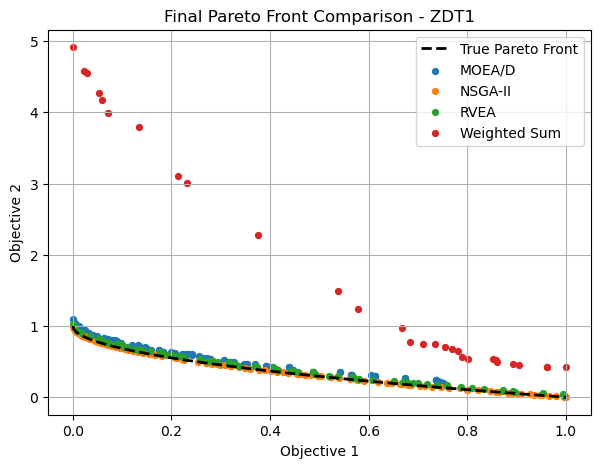

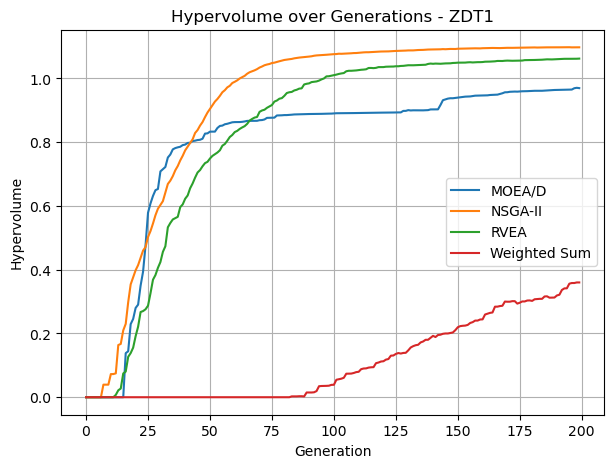

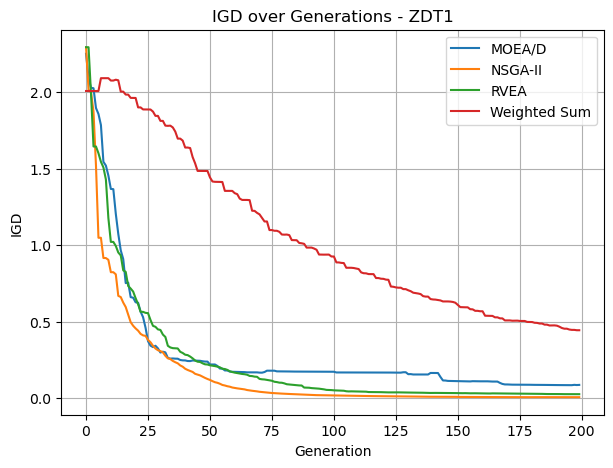

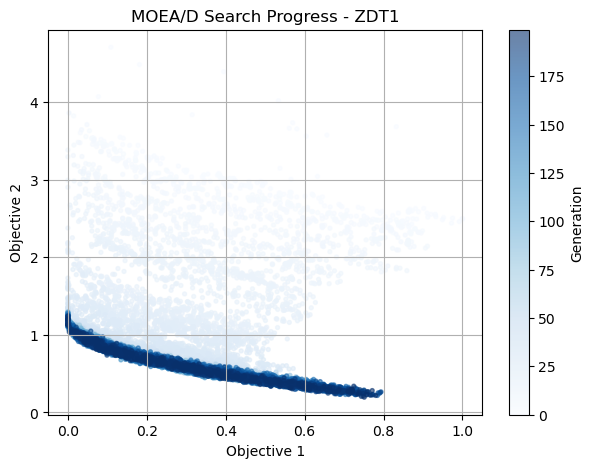

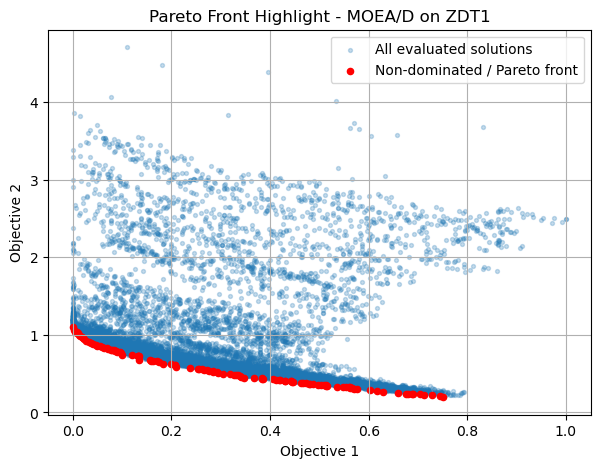

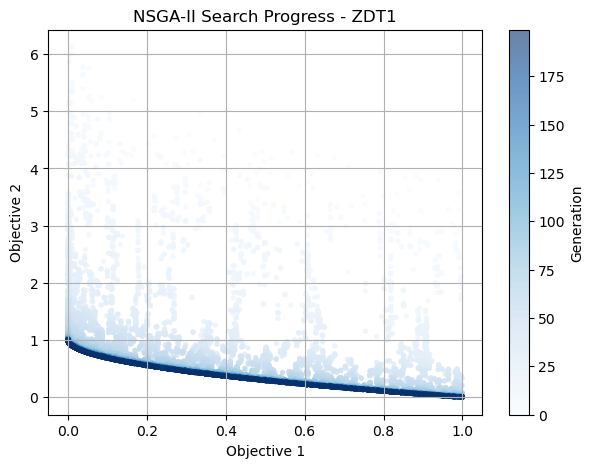

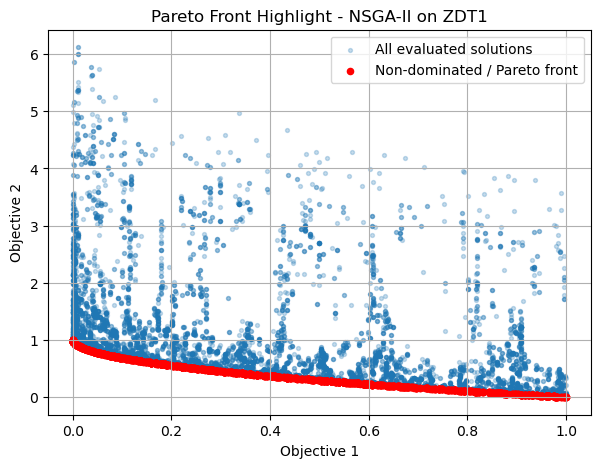

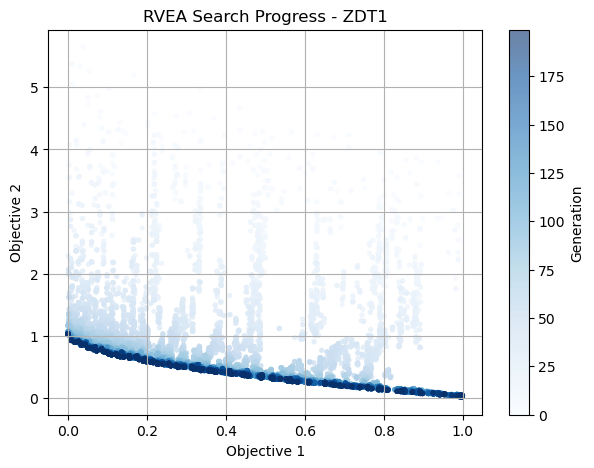

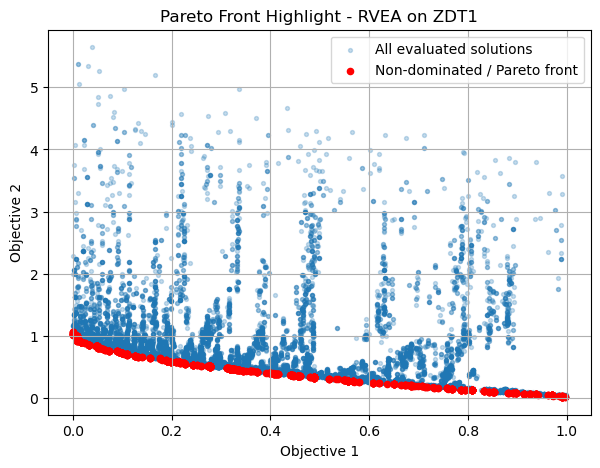

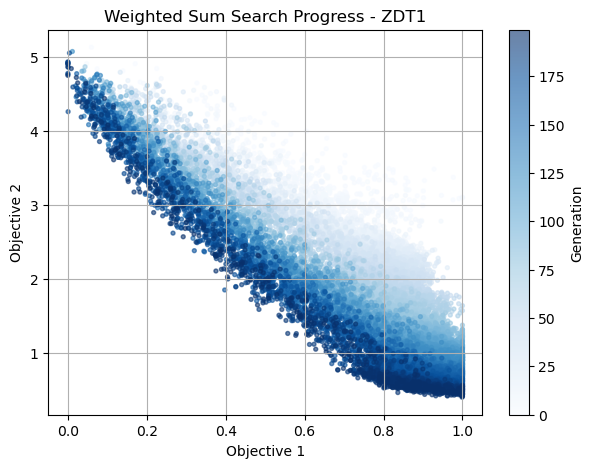

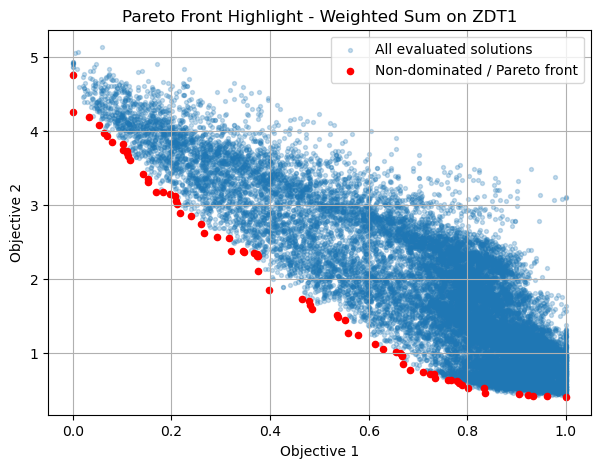


Running experiments for ZDT2...


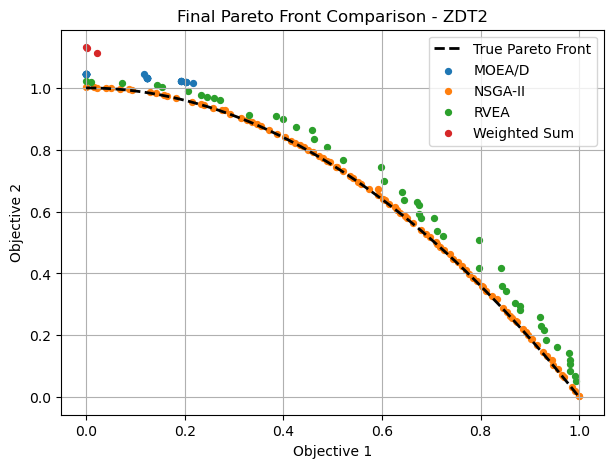

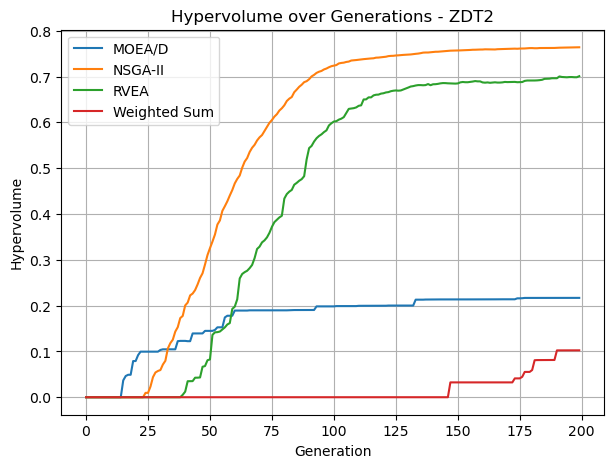

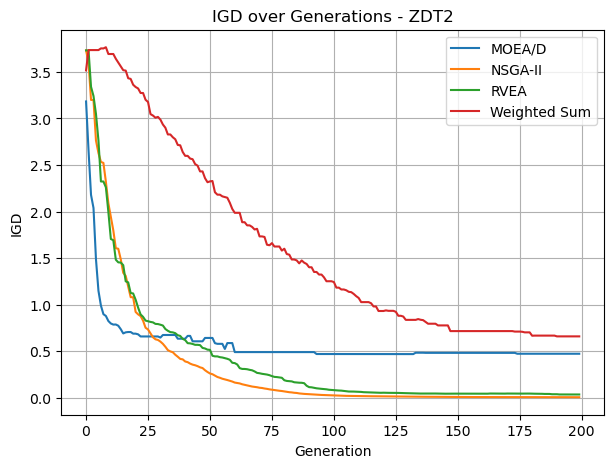

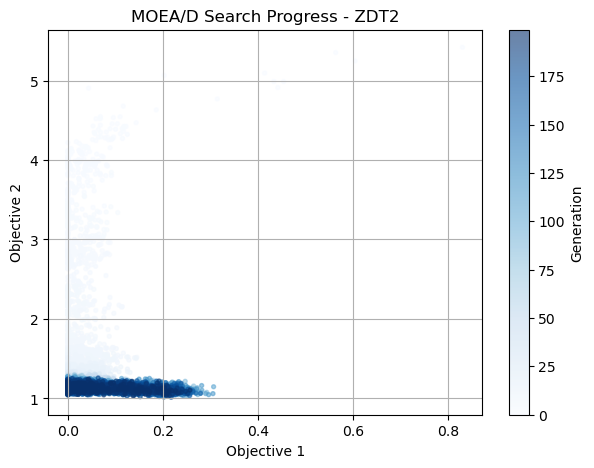

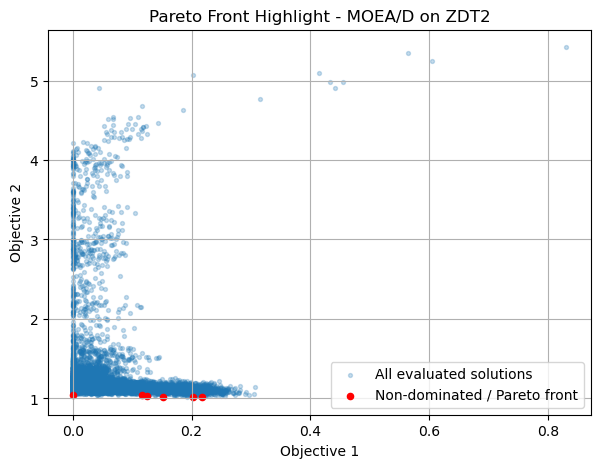

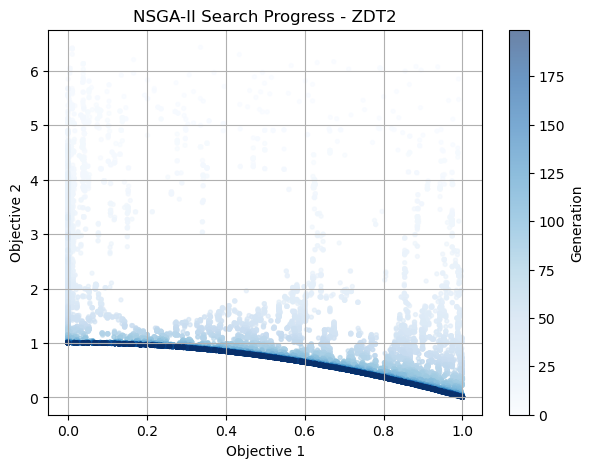

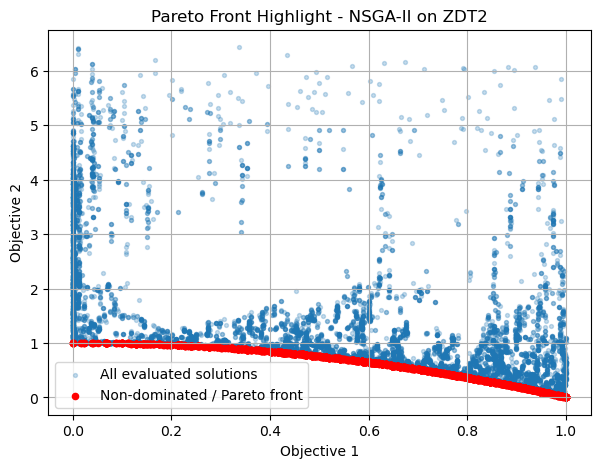

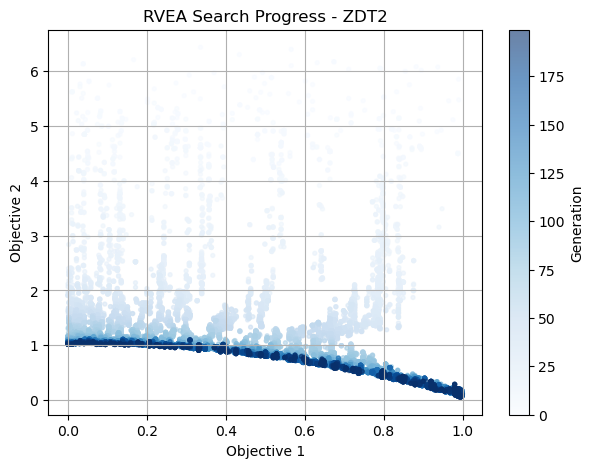

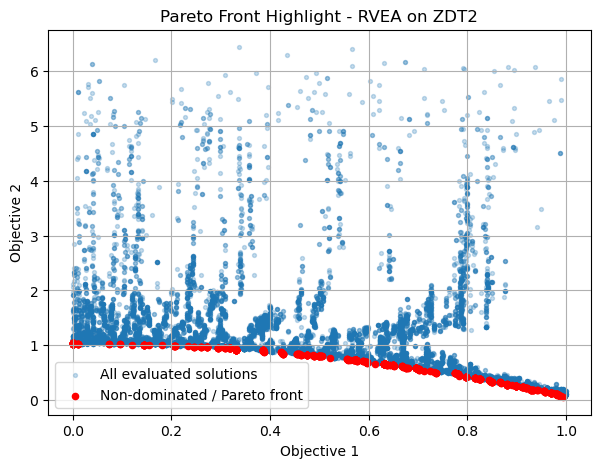

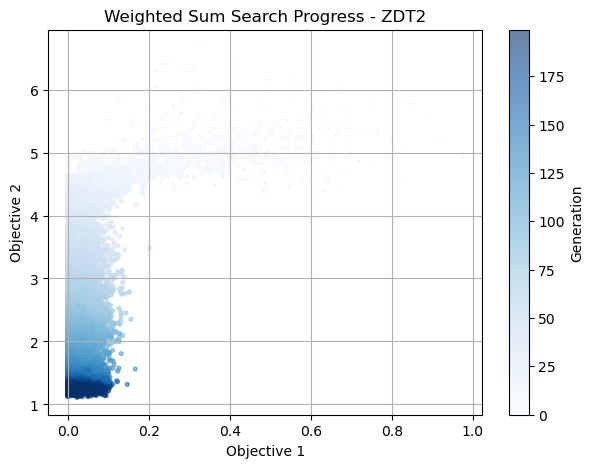

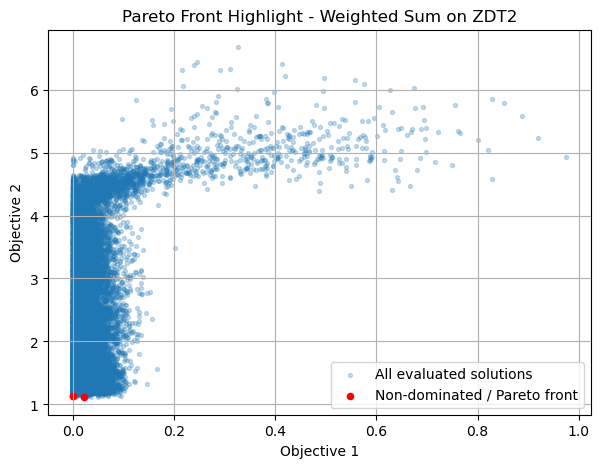


Running experiments for ZDT3...


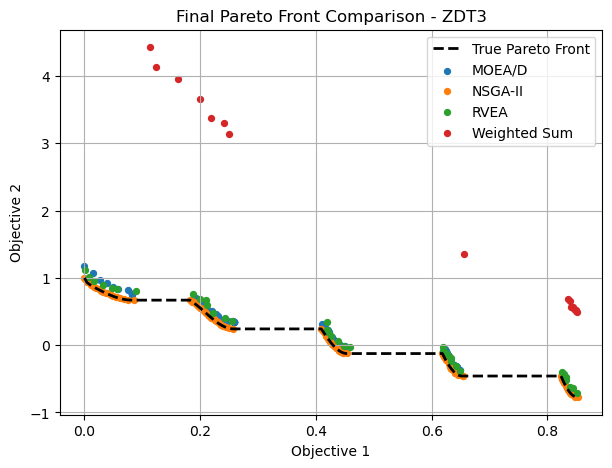

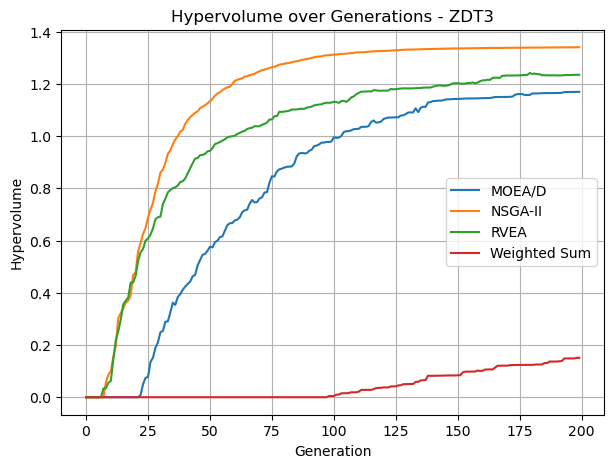

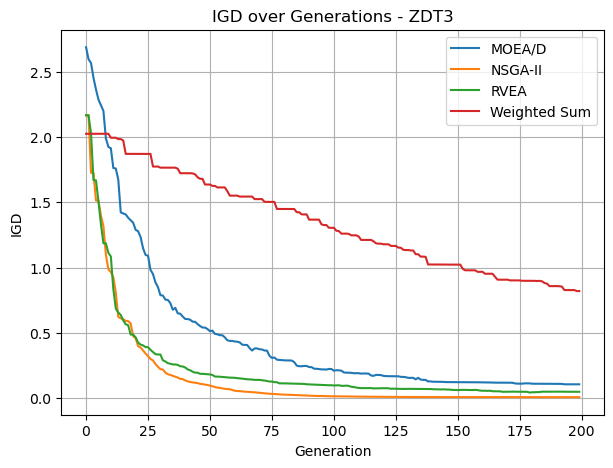

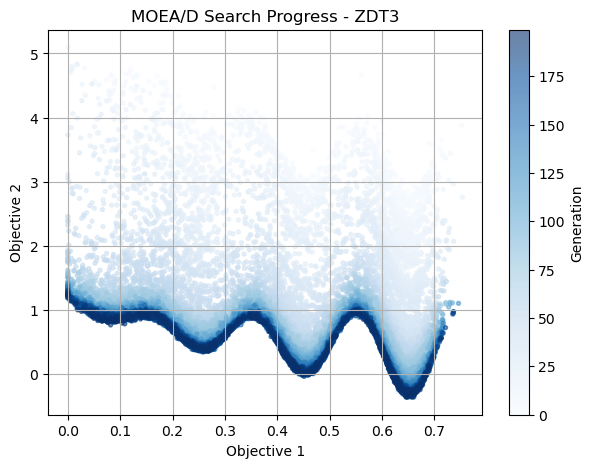

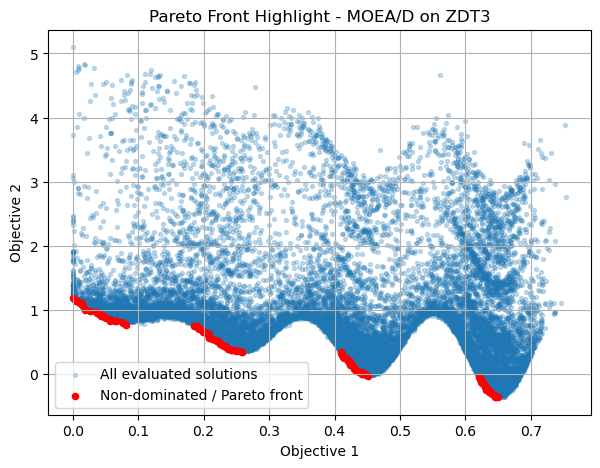

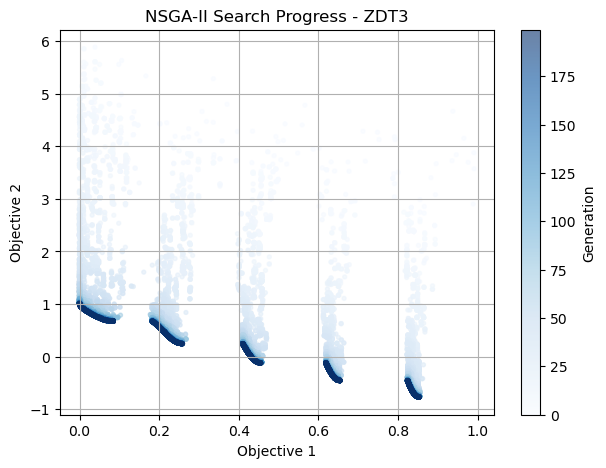

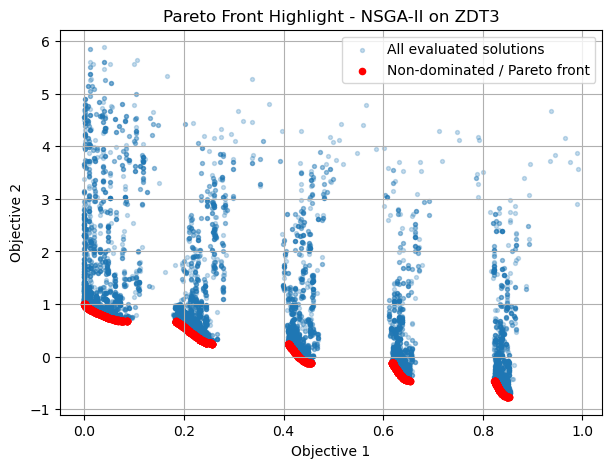

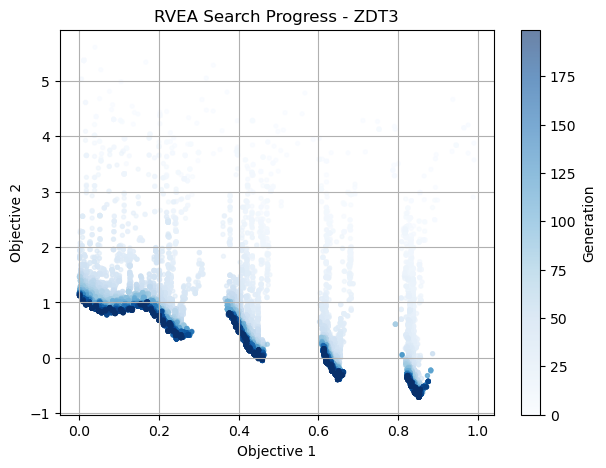

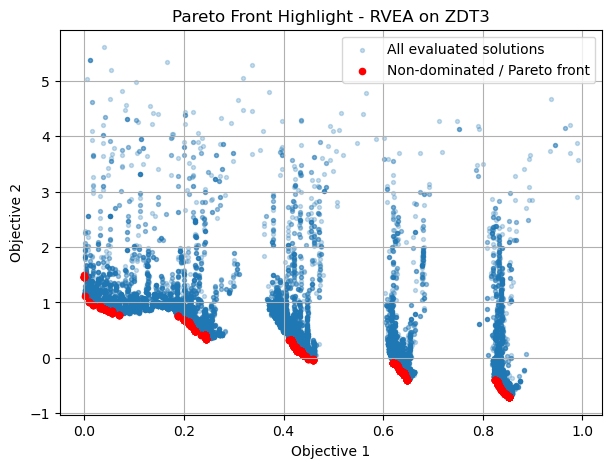

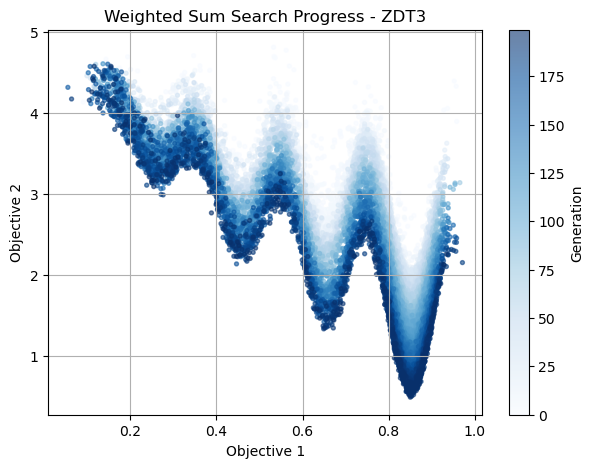

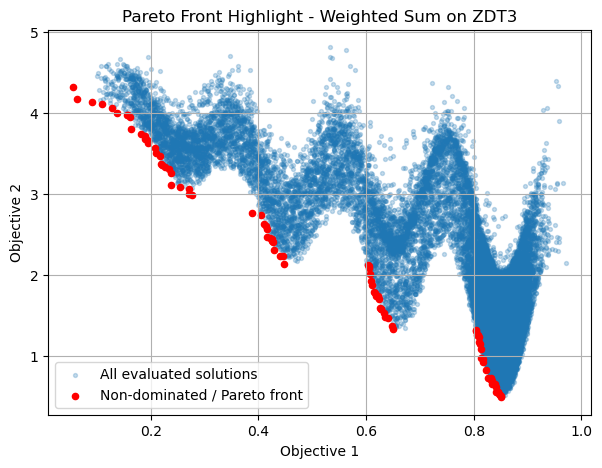

In [14]:
# --------------------------------------------------
# Run everything
# --------------------------------------------------
all_results = run_all_experiments(
    problem_names=("zdt1", "zdt2", "zdt3"),
    pop_size=100,
    generations=200,
    seed=1
)